# ch207 — Numerical Derivatives

**Part VII: Calculus**

---

## 1. Three Finite Difference Formulas

Derivatives are limits *(ch203–205)*, but computationally we can only take finite steps. Three standard approximations:

**Forward difference** (order O(h)):
$$f'(x) \approx \frac{f(x+h) - f(x)}{h}$$

**Backward difference** (order O(h)):
$$f'(x) \approx \frac{f(x) - f(x-h)}{h}$$

**Centered difference** (order O(h²)):
$$f'(x) \approx \frac{f(x+h) - f(x-h)}{2h}$$

The centered difference is superior: its error is O(h²) rather than O(h), meaning it converges faster. For the same h, it is typically 100–10000× more accurate.

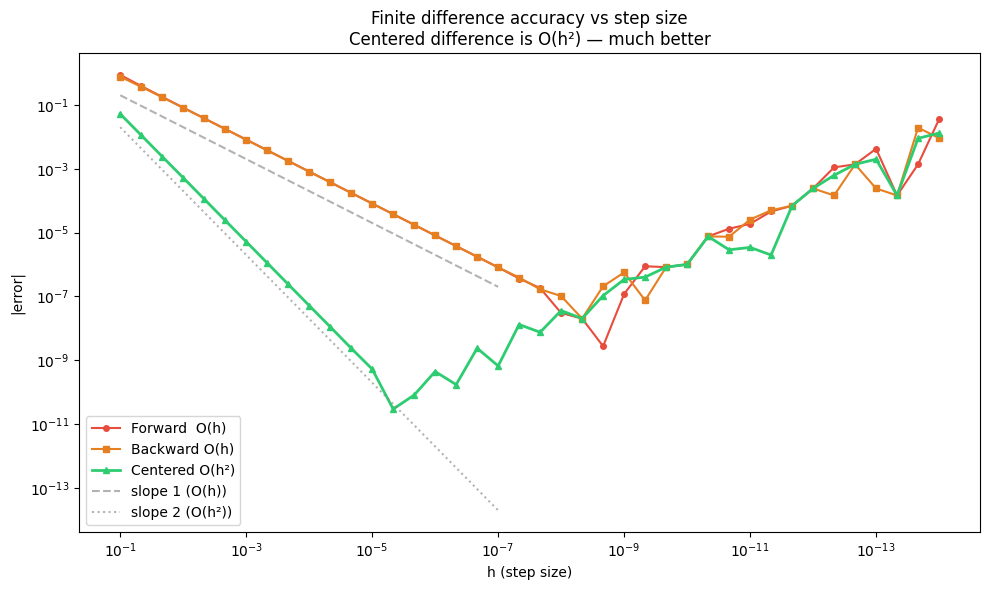

At h=1e-5:
  Forward:  error = 8.14e-05
  Centered: error = 5.32e-10


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def forward_diff(f, x, h=1e-5):
    return (f(x + h) - f(x)) / h

def backward_diff(f, x, h=1e-5):
    return (f(x) - f(x - h)) / h

def centered_diff(f, x, h=1e-5):
    return (f(x + h) - f(x - h)) / (2 * h)

# Test on f(x) = x^4 - 2x^2, f'(x) = 4x^3 - 4x
f     = lambda x: x**4 - 2*x**2
fp    = lambda x: 4*x**3 - 4*x

x0 = 1.3
true_val = fp(x0)

h_vals = np.logspace(-1, -14, 40)

err_fwd = [abs(forward_diff(f, x0, h) - true_val) for h in h_vals]
err_bwd = [abs(backward_diff(f, x0, h) - true_val) for h in h_vals]
err_cen = [abs(centered_diff(f, x0, h) - true_val) for h in h_vals]

fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(h_vals, err_fwd, 'o-', color='#e74c3c', markersize=4, linewidth=1.5, label='Forward  O(h)')
ax.loglog(h_vals, err_bwd, 's-', color='#e67e22', markersize=4, linewidth=1.5, label='Backward O(h)')
ax.loglog(h_vals, err_cen, '^-', color='#2ecc71', markersize=4, linewidth=2, label='Centered O(h²)')

# Reference slopes
h_ref = np.array([1e-1, 1e-7])
ax.loglog(h_ref, 2*h_ref,    '--', color='gray', alpha=0.6, label='slope 1 (O(h))')
ax.loglog(h_ref, 2*h_ref**2, ':',  color='gray', alpha=0.6, label='slope 2 (O(h²))')

ax.set_xlabel('h (step size)')
ax.set_ylabel('|error|')
ax.set_title('Finite difference accuracy vs step size\nCentered difference is O(h²) — much better')
ax.legend()
ax.invert_xaxis()
plt.tight_layout()
plt.show()

print(f'At h=1e-5:')
print(f'  Forward:  error = {abs(forward_diff(f, x0, 1e-5) - true_val):.2e}')
print(f'  Centered: error = {abs(centered_diff(f, x0, 1e-5) - true_val):.2e}')

## 2. Gradient Checking

**Gradient checking** is the practice of verifying analytically-derived gradients by comparing them to numerical estimates. This is essential when implementing custom loss functions or layers.

The procedure:
1. Compute the gradient analytically (what your code computes)
2. Compute the gradient numerically (centered difference)
3. Compare — relative error should be < 1e-5

In [2]:
def gradient_check(loss_fn, params, analytical_grad, h=1e-5, tol=1e-4, verbose=True):
    """
    Check analytical gradient against numerical gradient.
    
    params: 1D numpy array of parameters
    analytical_grad: gradient array (same shape as params)
    """
    n = len(params)
    numerical_grad = np.zeros(n)
    
    for i in range(n):
        p_plus = params.copy(); p_plus[i]  += h
        p_minus = params.copy(); p_minus[i] -= h
        numerical_grad[i] = (loss_fn(p_plus) - loss_fn(p_minus)) / (2 * h)
    
    # Relative error: ||analytical - numerical|| / ||analytical + numerical||
    diff = np.linalg.norm(analytical_grad - numerical_grad)
    denom = np.linalg.norm(analytical_grad) + np.linalg.norm(numerical_grad)
    rel_error = diff / (denom + 1e-15)
    
    if verbose:
        print(f'Gradient check:')
        print(f'  Analytical grad: {analytical_grad}')
        print(f'  Numerical grad:  {numerical_grad}')
        print(f'  Relative error:  {rel_error:.2e}')
        print(f'  Status: {"PASS" if rel_error < tol else "FAIL"} (tol={tol})')
    
    return rel_error, numerical_grad


# Example 1: MSE loss for linear regression
# Loss = (1/N) sum (w·x_i - y_i)^2
# Grad_w = (2/N) X^T (Xw - y)
np.random.seed(42)
N = 20
X = np.random.randn(N, 3)
y = X @ np.array([1.5, -0.5, 2.0]) + 0.1 * np.random.randn(N)

def mse_loss(w):
    residuals = X @ w - y
    return np.mean(residuals**2)

def mse_grad(w):
    residuals = X @ w - y
    return (2/N) * X.T @ residuals

w = np.array([0.5, 0.5, 0.5])
analytical = mse_grad(w)
print('=== MSE Loss Gradient Check ===')
gradient_check(mse_loss, w, analytical)
print()

# Example 2: Deliberate bug — wrong analytical gradient (missing factor of 2)
def mse_grad_BUGGY(w):
    residuals = X @ w - y
    return (1/N) * X.T @ residuals  # missing factor of 2

print('=== BUGGY Gradient Check (should FAIL) ===')
gradient_check(mse_loss, w, mse_grad_BUGGY(w))

=== MSE Loss Gradient Check ===
Gradient check:
  Analytical grad: [-0.53916839  1.96213827 -2.35129187]
  Numerical grad:  [-0.53916839  1.96213827 -2.35129187]
  Relative error:  8.84e-12
  Status: PASS (tol=0.0001)

=== BUGGY Gradient Check (should FAIL) ===
Gradient check:
  Analytical grad: [-0.26958419  0.98106914 -1.17564593]
  Numerical grad:  [-0.53916839  1.96213827 -2.35129187]
  Relative error:  3.33e-01
  Status: FAIL (tol=0.0001)


(np.float64(0.3333333333266106),
 array([-0.53916839,  1.96213827, -2.35129187]))

## 3. Second-Order Finite Differences

We can also approximate higher derivatives numerically:

$$f''(x) \approx \frac{f(x+h) - 2f(x) + f(x-h)}{h^2}$$

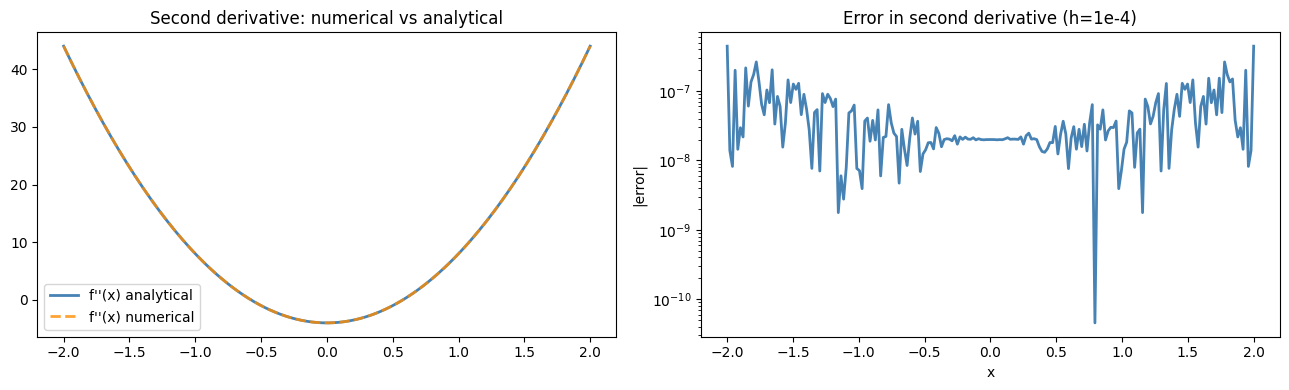

Max error: 4.43e-07


In [3]:
def second_derivative(f, x, h=1e-4):
    """Centered finite difference for second derivative. O(h^2) accurate."""
    return (f(x + h) - 2*f(x) + f(x - h)) / h**2

# f(x) = x^4 - 2x^2,  f''(x) = 12x^2 - 4
f   = lambda x: x**4 - 2*x**2
fpp = lambda x: 12*x**2 - 4

x_vals = np.linspace(-2, 2, 200)
num_fpp = second_derivative(f, x_vals)
true_fpp = fpp(x_vals)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(x_vals, true_fpp, color='steelblue', linewidth=2, label="f''(x) analytical")
axes[0].plot(x_vals, num_fpp, color='darkorange', linewidth=2, linestyle='--', label="f''(x) numerical", alpha=0.8)
axes[0].set_title('Second derivative: numerical vs analytical')
axes[0].legend()

axes[1].semilogy(x_vals, np.abs(num_fpp - true_fpp) + 1e-16, color='steelblue', linewidth=2)
axes[1].set_title('Error in second derivative (h=1e-4)')
axes[1].set_ylabel('|error|')
axes[1].set_xlabel('x')

plt.tight_layout()
plt.show()

print(f'Max error: {np.abs(num_fpp - true_fpp).max():.2e}')

## 4. When to Use Numerical Derivatives

| Situation | Use |
|-----------|-----|
| Verifying an analytical gradient | Gradient check with centered difference |
| Black-box function (no source) | Numerical gradient for optimization |
| Rapid prototyping | Numerical gradient — get it right, optimize later |
| Production training | Automatic differentiation (ch208) — faster and exact |

---

## 5. Summary

- Forward/backward difference: O(h) accuracy — fine for quick checks
- Centered difference: O(h²) accuracy — standard for gradient checking
- Optimal h ≈ √(ε_machine) ≈ 1e-8 for first derivatives (balances truncation and roundoff)
- Gradient checking: relative error < 1e-5 means the analytical gradient is correct
- Second derivative: (f(x+h) - 2f(x) + f(x-h)) / h², optimal h ≈ ε^(1/3) ≈ 1e-5

---

## 6. Forward References

Numerical derivatives are a debugging tool. The production replacement is automatic differentiation, the subject of ch208 — Automatic Differentiation. Gradient checking will be used again in the projects ch228–ch230 to verify that manually implemented backpropagation is correct. The second derivative approximation connects to ch217 — Second Derivatives and the Hessian matrix used in second-order optimizers.